In [1]:
#auditing
import pandas as pd
import numpy as np

file_path = r"C:\Users\User\Desktop\Final Year Project\Data\FeatureDataset_RiskProgress.xlsx"

# Read all sheets
xls = pd.ExcelFile(file_path)
print("Sheets:", xls.sheet_names)

audit_results = []

for sheet in xls.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)
    
    print("\n" + "="*80)
    print(f"SHEET: {sheet}")
    print("="*80)
    
    print("Shape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())
    
    # Missing values
    missing = df.isna().sum().sort_values(ascending=False)
    missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
    
    missing_df = pd.DataFrame({
        "missing_count": missing,
        "missing_pct": missing_pct
    })
    
    print("\nTop missing columns:")
    print(missing_df[missing_df["missing_count"] > 0].head(20))
    
    # Target distribution
    if "RISK_BAND" in df.columns:
        print("\nRISK_BAND distribution:")
        print(df["RISK_BAND"].value_counts(dropna=False))
        print(df["RISK_BAND"].value_counts(normalize=True, dropna=False) * 100)
    
    # Numeric summary
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if num_cols:
        desc = df[num_cols].describe().T
        print("\nNumeric summary:")
        print(desc[["mean", "std", "min", "max"]].head(20))
    
    # Near-constant columns
    nunique = df.nunique(dropna=False).sort_values()
    low_var = nunique[nunique <= 2]
    if len(low_var) > 0:
        print("\nLow-variation columns (<=2 unique values):")
        print(low_var)
    
    audit_results.append({
        "sheet": sheet,
        "rows": df.shape[0],
        "cols": df.shape[1],
        "risk_counts": df["RISK_BAND"].value_counts(dropna=False).to_dict() if "RISK_BAND" in df.columns else None
    })

summary_df = pd.DataFrame(audit_results)
print("\n" + "="*80)
print("AUDIT SUMMARY")
print("="*80)
print(summary_df)

Sheets: ['Y1S1', 'Y1S2', 'Y2S1', 'Y2S2', 'Y3S1', 'Y3S2', 'Y4S1', 'Y4S2']

SHEET: Y1S1
Shape: (617, 32)

Columns:
['REGNO', 'checkpoint_idx', 'checkpoint_sheet', 'credits_attempted', 'module_count', 'wavg_mark', 'avg_mark', 'mark_min', 'mark_max', 'mark_std', 'fail_count', 'pass_count', 'credits_L1', 'credits_L2', 'credits_L3', 'credits_L4', 'wavg_mark_L1', 'wavg_mark_L2', 'wavg_mark_L3', 'wavg_mark_L4', 'credits_T1', 'credits_T2', 'credits_T3', 'credits_T4', 'credits_T5', 'wavg_mark_T1', 'wavg_mark_T2', 'wavg_mark_T3', 'wavg_mark_T4', 'wavg_mark_T5', 'RISK_BAND', 'RISK_BAND_Y4S2']

Top missing columns:
                missing_count  missing_pct
wavg_mark_L4              616    99.837925
wavg_mark_L3              613    99.351702
wavg_mark_L2              473    76.661264
wavg_mark_T1              447    72.447326
wavg_mark_T3              445    72.123177
wavg_mark_T4              422    68.395462
wavg_mark_T2              118    19.124797
RISK_BAND_Y4S2             61     9.886548
wav

In [2]:
#cheecking if dropping rows
import pandas as pd

file_path = r"C:\Users\User\Desktop\Final Year Project\Data\FeatureDataset_RiskProgress.xlsx"
xls = pd.ExcelFile(file_path)

for sheet in xls.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)
    
    before = len(df)
    after_drop = len(df.dropna())
    
    print(f"{sheet}: before={before}, after_dropna={after_drop}, dropped={before-after_drop}")

Y1S1: before=617, after_dropna=0, dropped=617
Y1S2: before=841, after_dropna=0, dropped=841
Y2S1: before=836, after_dropna=1, dropped=835
Y2S2: before=828, after_dropna=0, dropped=828
Y3S1: before=819, after_dropna=0, dropped=819
Y3S2: before=802, after_dropna=0, dropped=802
Y4S1: before=746, after_dropna=0, dropped=746
Y4S2: before=753, after_dropna=0, dropped=753


In [3]:
import pandas as pd

file_path = r"C:\Users\User\Desktop\Final Year Project\Data\FeatureDataset_RiskProgress.xlsx"
output_path = r"C:\Users\User\Desktop\Final Year Project\Data\FeatureDataset_RiskProgress_structuralfill.xlsx"

xls = pd.ExcelFile(file_path)

pairs = [
    ("credits_L1", "wavg_mark_L1"),
    ("credits_L2", "wavg_mark_L2"),
    ("credits_L3", "wavg_mark_L3"),
    ("credits_L4", "wavg_mark_L4"),
    ("credits_T1", "wavg_mark_T1"),
    ("credits_T2", "wavg_mark_T2"),
    ("credits_T3", "wavg_mark_T3"),
    ("credits_T4", "wavg_mark_T4"),
    ("credits_T5", "wavg_mark_T5"),
]

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    for sheet in xls.sheet_names:
        df = pd.read_excel(file_path, sheet_name=sheet)

        print(f"\n--- {sheet} ---")
        for credit_col, mark_col in pairs:
            if credit_col in df.columns and mark_col in df.columns:
                fill_mask = (df[credit_col] == 0) & (df[mark_col].isna())
                unexpected_mask = (df[credit_col] > 0) & (df[mark_col].isna())

                print(
                    f"{mark_col}: filled={fill_mask.sum()}, unexpected_missing={unexpected_mask.sum()}"
                )

                df.loc[fill_mask, mark_col] = 0

        df.to_excel(writer, sheet_name=sheet, index=False)

print(f"\nSaved filled dataset to:\n{output_path}")


--- Y1S1 ---
wavg_mark_L1: filled=2, unexpected_missing=0
wavg_mark_L2: filled=464, unexpected_missing=9
wavg_mark_L3: filled=612, unexpected_missing=1
wavg_mark_L4: filled=616, unexpected_missing=0
wavg_mark_T1: filled=447, unexpected_missing=0
wavg_mark_T2: filled=117, unexpected_missing=1
wavg_mark_T3: filled=443, unexpected_missing=2
wavg_mark_T4: filled=420, unexpected_missing=2
wavg_mark_T5: filled=8, unexpected_missing=2

--- Y1S2 ---
wavg_mark_L1: filled=11, unexpected_missing=0
wavg_mark_L2: filled=214, unexpected_missing=0
wavg_mark_L3: filled=814, unexpected_missing=1
wavg_mark_L4: filled=836, unexpected_missing=0
wavg_mark_T1: filled=717, unexpected_missing=0
wavg_mark_T2: filled=215, unexpected_missing=0
wavg_mark_T3: filled=369, unexpected_missing=0
wavg_mark_T4: filled=411, unexpected_missing=0
wavg_mark_T5: filled=20, unexpected_missing=2

--- Y2S1 ---
wavg_mark_L1: filled=105, unexpected_missing=0
wavg_mark_L2: filled=52, unexpected_missing=0
wavg_mark_L3: filled=555,

In [4]:
import pandas as pd

file_path = r"C:\Users\User\Desktop\Final Year Project\Data\FeatureDataset_RiskProgress_structuralfill.xlsx"
xls = pd.ExcelFile(file_path)

for sheet in xls.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)

    before = len(df)
    after_drop = len(df.dropna())

    print(f"{sheet}: before={before}, after_dropna={after_drop}, dropped={before-after_drop}")

Y1S1: before=617, after_dropna=546, dropped=71
Y1S2: before=841, after_dropna=768, dropped=73
Y2S1: before=836, after_dropna=770, dropped=66
Y2S2: before=828, after_dropna=768, dropped=60
Y3S1: before=819, after_dropna=761, dropped=58
Y3S2: before=802, after_dropna=749, dropped=53
Y4S1: before=746, after_dropna=731, dropped=15
Y4S2: before=753, after_dropna=744, dropped=9


In [5]:
import pandas as pd

file_path = r"C:\Users\User\Desktop\Final Year Project\Data\FeatureDataset_RiskProgress_structuralfill.xlsx"
xls = pd.ExcelFile(file_path)

for sheet in xls.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)

    missing_count = df.isna().sum()
    missing_pct = df.isna().mean() * 100

    missing_df = pd.DataFrame({
        "missing_count": missing_count,
        "missing_pct": missing_pct
    })

    missing_df = missing_df[missing_df["missing_count"] > 0].sort_values(
        by="missing_count", ascending=False
    )

    print("\n" + "="*80)
    print(f"SHEET: {sheet}")
    print("="*80)
    print(missing_df if not missing_df.empty else "No missing values")


SHEET: Y1S1
                missing_count  missing_pct
RISK_BAND_Y4S2             61     9.886548
wavg_mark_L2                9     1.458671
wavg_mark                   2     0.324149
wavg_mark_T3                2     0.324149
wavg_mark_T4                2     0.324149
wavg_mark_T5                2     0.324149
wavg_mark_L3                1     0.162075
wavg_mark_T2                1     0.162075

SHEET: Y1S2
                missing_count  missing_pct
RISK_BAND_Y4S2             71     8.442331
wavg_mark                   3     0.356718
wavg_mark_T5                2     0.237812
wavg_mark_L3                1     0.118906

SHEET: Y2S1
                missing_count  missing_pct
RISK_BAND_Y4S2             66     7.894737
wavg_mark                   2     0.239234

SHEET: Y2S2
                missing_count  missing_pct
RISK_BAND_Y4S2             60     7.246377
wavg_mark                   5     0.603865

SHEET: Y3S1
                missing_count  missing_pct
RISK_BAND_Y4S2             55   

In [6]:
import pandas as pd

file_path = r"C:\Users\User\Desktop\Final Year Project\Data\FeatureDataset_RiskProgress_structuralfill.xlsx"
xls = pd.ExcelFile(file_path)

for sheet in xls.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)

    dropped_rows = df[df.isna().any(axis=1)].copy()

    print("\n" + "="*100)
    print(f"SHEET: {sheet}")
    print("="*100)
    print(f"Rows with any missing values: {len(dropped_rows)}")

    if len(dropped_rows) > 0:
        cols_missing_in_dropped = dropped_rows.isna().sum()
        cols_missing_in_dropped = cols_missing_in_dropped[cols_missing_in_dropped > 0].sort_values(ascending=False)

        print("\nColumns causing row drop:")
        print(cols_missing_in_dropped)

        print("\nSample dropped rows (missing columns only shown):")
        sample = dropped_rows.head(10)
        missing_only = sample.loc[:, sample.isna().any()]
        print(missing_only)


SHEET: Y1S1
Rows with any missing values: 71

Columns causing row drop:
RISK_BAND_Y4S2    61
wavg_mark_L2       9
wavg_mark          2
wavg_mark_T3       2
wavg_mark_T4       2
wavg_mark_T5       2
wavg_mark_L3       1
wavg_mark_T2       1
dtype: int64

Sample dropped rows (missing columns only shown):
    RISK_BAND_Y4S2
31             NaN
43             NaN
48             NaN
98             NaN
103            NaN
163            NaN
181            NaN
193            NaN
195            NaN
203            NaN

SHEET: Y1S2
Rows with any missing values: 73

Columns causing row drop:
RISK_BAND_Y4S2    71
wavg_mark          3
wavg_mark_T5       2
wavg_mark_L3       1
dtype: int64

Sample dropped rows (missing columns only shown):
    RISK_BAND_Y4S2
42             NaN
47             NaN
97             NaN
102            NaN
179            NaN
199            NaN
202            NaN
205            NaN
308            NaN
312            NaN

SHEET: Y2S1
Rows with any missing values: 66

Columns c

In [7]:
import pandas as pd

file_path = r"C:\Users\User\Desktop\Final Year Project\Data\FeatureDataset_RiskProgress_structuralfill.xlsx"
xls = pd.ExcelFile(file_path)

for sheet in xls.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)

    print(f"\n--- {sheet} ---")
    if "RISK_BAND_Y4S2" in df.columns:
        print("Missing RISK_BAND_Y4S2:", df["RISK_BAND_Y4S2"].isna().sum())
    if "wavg_mark" in df.columns:
        print("Missing wavg_mark:", df["wavg_mark"].isna().sum())
    if "wavg_mark_L1" in df.columns:
        print("Missing wavg_mark_L1:", df["wavg_mark_L1"].isna().sum())


--- Y1S1 ---
Missing RISK_BAND_Y4S2: 61
Missing wavg_mark: 2
Missing wavg_mark_L1: 0

--- Y1S2 ---
Missing RISK_BAND_Y4S2: 71
Missing wavg_mark: 3
Missing wavg_mark_L1: 0

--- Y2S1 ---
Missing RISK_BAND_Y4S2: 66
Missing wavg_mark: 2
Missing wavg_mark_L1: 0

--- Y2S2 ---
Missing RISK_BAND_Y4S2: 60
Missing wavg_mark: 5
Missing wavg_mark_L1: 0

--- Y3S1 ---
Missing RISK_BAND_Y4S2: 55
Missing wavg_mark: 8
Missing wavg_mark_L1: 0

--- Y3S2 ---
Missing RISK_BAND_Y4S2: 47
Missing wavg_mark: 11
Missing wavg_mark_L1: 0

--- Y4S1 ---
Missing RISK_BAND_Y4S2: 5
Missing wavg_mark: 13
Missing wavg_mark_L1: 0

--- Y4S2 ---
Missing RISK_BAND_Y4S2: 0
Missing wavg_mark: 9
Missing wavg_mark_L1: 0


In [8]:
import pandas as pd

file_path = r"C:\Users\User\Desktop\Final Year Project\Data\FeatureDataset_RiskProgress_structuralfill.xlsx"
xls = pd.ExcelFile(file_path)

target_col = "RISK_BAND_Y4S2"   # change if needed
exclude_cols = ["REGNO", "checkpoint_idx", "checkpoint_sheet", "RISK_BAND"]

for sheet in xls.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)

    feature_cols = [c for c in df.columns if c not in exclude_cols + [target_col]]
    model_cols = feature_cols + [target_col]

    before = len(df)
    after = len(df[model_cols].dropna())

    print(f"{sheet}: before={before}, usable_for_model={after}, dropped={before-after}")

Y1S1: before=617, usable_for_model=546, dropped=71
Y1S2: before=841, usable_for_model=768, dropped=73
Y2S1: before=836, usable_for_model=770, dropped=66
Y2S2: before=828, usable_for_model=768, dropped=60
Y3S1: before=819, usable_for_model=761, dropped=58
Y3S2: before=802, usable_for_model=749, dropped=53
Y4S1: before=746, usable_for_model=731, dropped=15
Y4S2: before=753, usable_for_model=744, dropped=9


In [9]:
import pandas as pd

file_path = r"C:\Users\User\Desktop\Final Year Project\Data\FeatureDataset_RiskProgress_structuralfill.xlsx"

df = pd.read_excel(file_path, sheet_name="Y1S1")

cols_to_check = [
    "REGNO", "credits_L2", "wavg_mark_L2",
    "credits_L3", "wavg_mark_L3",
    "credits_T2", "wavg_mark_T2",
    "credits_T3", "wavg_mark_T3",
    "credits_T4", "wavg_mark_T4",
    "credits_T5", "wavg_mark_T5",
    "credits_attempted", "module_count", "wavg_mark", "avg_mark",
    "RISK_BAND_Y4S2"
]

problem_rows = df[df[cols_to_check].isna().any(axis=1)]
print(problem_rows[cols_to_check].head(20))

      REGNO  credits_L2  wavg_mark_L2  credits_L3  wavg_mark_L3  credits_T2  \
31   100033           0          0.00           0           0.0           4   
43   100046           0          0.00           0           0.0           4   
48   100051           0          0.00           0           0.0           8   
98   100103           0          0.00           0           0.0           4   
103  100108           0          0.00           0           0.0           4   
163  100173           0          0.00           0           0.0           0   
181  100195           0          0.00           0           0.0           0   
193  100209           0          0.00           0           0.0           0   
195  100211           0          0.00           0           0.0           0   
203  101004           0          0.00           0           0.0           0   
206  101007           0          0.00           0           0.0           0   
209  101010           0          0.00           0   

In [10]:
import pandas as pd

file_path = r"C:\Users\User\Desktop\Final Year Project\Data\FeatureDataset_RiskProgress.xlsx"
output_path = r"C:\Users\User\Desktop\Final Year Project\Data\FeatureDataset_RiskProgress_structuralfill_v2.xlsx"

xls = pd.ExcelFile(file_path)

credit_cols = [
    "credits_L1", "credits_L2", "credits_L3", "credits_L4",
    "credits_T1", "credits_T2", "credits_T3", "credits_T4", "credits_T5"
]

pairs = [
    ("credits_L1", "wavg_mark_L1"),
    ("credits_L2", "wavg_mark_L2"),
    ("credits_L3", "wavg_mark_L3"),
    ("credits_L4", "wavg_mark_L4"),
    ("credits_T1", "wavg_mark_T1"),
    ("credits_T2", "wavg_mark_T2"),
    ("credits_T3", "wavg_mark_T3"),
    ("credits_T4", "wavg_mark_T4"),
    ("credits_T5", "wavg_mark_T5"),
]

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    for sheet in xls.sheet_names:
        df = pd.read_excel(file_path, sheet_name=sheet)

        print(f"\n--- {sheet} ---")

        # Step 1: fill missing credits structurally with 0
        for col in credit_cols:
            if col in df.columns:
                n_missing = df[col].isna().sum()
                if n_missing > 0:
                    print(f"{col}: filling missing credits with 0 -> {n_missing}")
                    df[col] = df[col].fillna(0)

        # Step 2: fill missing weighted marks where corresponding credits are 0
        for credit_col, mark_col in pairs:
            if credit_col in df.columns and mark_col in df.columns:
                fill_mask = (df[credit_col] == 0) & (df[mark_col].isna())
                unexpected_mask = (df[credit_col] > 0) & (df[mark_col].isna())

                print(
                    f"{mark_col}: filled={fill_mask.sum()}, unexpected_missing={unexpected_mask.sum()}"
                )

                df.loc[fill_mask, mark_col] = 0

        df.to_excel(writer, sheet_name=sheet, index=False)

print(f"\nSaved to:\n{output_path}")


--- Y1S1 ---
wavg_mark_L1: filled=2, unexpected_missing=0
wavg_mark_L2: filled=464, unexpected_missing=9
wavg_mark_L3: filled=612, unexpected_missing=1
wavg_mark_L4: filled=616, unexpected_missing=0
wavg_mark_T1: filled=447, unexpected_missing=0
wavg_mark_T2: filled=117, unexpected_missing=1
wavg_mark_T3: filled=443, unexpected_missing=2
wavg_mark_T4: filled=420, unexpected_missing=2
wavg_mark_T5: filled=8, unexpected_missing=2

--- Y1S2 ---
wavg_mark_L1: filled=11, unexpected_missing=0
wavg_mark_L2: filled=214, unexpected_missing=0
wavg_mark_L3: filled=814, unexpected_missing=1
wavg_mark_L4: filled=836, unexpected_missing=0
wavg_mark_T1: filled=717, unexpected_missing=0
wavg_mark_T2: filled=215, unexpected_missing=0
wavg_mark_T3: filled=369, unexpected_missing=0
wavg_mark_T4: filled=411, unexpected_missing=0
wavg_mark_T5: filled=20, unexpected_missing=2

--- Y2S1 ---
wavg_mark_L1: filled=105, unexpected_missing=0
wavg_mark_L2: filled=52, unexpected_missing=0
wavg_mark_L3: filled=555,

In [11]:
import pandas as pd

file_path = r"C:\Users\User\Desktop\Final Year Project\Data\FeatureDataset_RiskProgress_structuralfill_v2.xlsx"
xls = pd.ExcelFile(file_path)

for sheet in xls.sheet_names:
    df = pd.read_excel(file_path, sheet_name=sheet)

    missing_df = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_pct": df.isna().mean() * 100
    })

    missing_df = missing_df[missing_df["missing_count"] > 0].sort_values(
        "missing_count", ascending=False
    )

    print("\n" + "="*80)
    print(sheet)
    print("="*80)
    print(missing_df if not missing_df.empty else "No missing values")


Y1S1
                missing_count  missing_pct
RISK_BAND_Y4S2             61     9.886548
wavg_mark_L2                9     1.458671
wavg_mark                   2     0.324149
wavg_mark_T3                2     0.324149
wavg_mark_T4                2     0.324149
wavg_mark_T5                2     0.324149
wavg_mark_L3                1     0.162075
wavg_mark_T2                1     0.162075

Y1S2
                missing_count  missing_pct
RISK_BAND_Y4S2             71     8.442331
wavg_mark                   3     0.356718
wavg_mark_T5                2     0.237812
wavg_mark_L3                1     0.118906

Y2S1
                missing_count  missing_pct
RISK_BAND_Y4S2             66     7.894737
wavg_mark                   2     0.239234

Y2S2
                missing_count  missing_pct
RISK_BAND_Y4S2             60     7.246377
wavg_mark                   5     0.603865

Y3S1
                missing_count  missing_pct
RISK_BAND_Y4S2             55     6.715507
wavg_mark               

In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score, accuracy_score

# =========================
# SETTINGS
# =========================
file_path = r"C:\Users\User\Desktop\Final Year Project\Data\FeatureDataset_RiskProgress_structuralfill_v2.xlsx"
sheet_name = "Y1S1"
target_col = "RISK_BAND_Y4S2"

# Choose the class you care about most
focus_class = "High Risk"

# =========================
# LOAD DATA
# =========================
df = pd.read_excel(file_path, sheet_name=sheet_name)

# Keep only rows with target available
df = df[df[target_col].notna()].copy()

print("Sheet:", sheet_name)
print("Rows after keeping non-missing target:", len(df))
print("\nTarget distribution:")
print(df[target_col].value_counts(dropna=False))

# =========================
# FEATURE GROUPS
# =========================
LOAD = [
    "credits_attempted", "module_count"
]

MARK_SUMMARY = [
    "wavg_mark", "avg_mark", "mark_min", "mark_max", "mark_std",
    "fail_count", "pass_count"
]

LEVEL = [
    "credits_L1", "credits_L2", "credits_L3", "credits_L4",
    "wavg_mark_L1", "wavg_mark_L2", "wavg_mark_L3", "wavg_mark_L4"
]

TYPE = [
    "credits_T1", "credits_T2", "credits_T3", "credits_T4", "credits_T5",
    "wavg_mark_T1", "wavg_mark_T2", "wavg_mark_T3", "wavg_mark_T4", "wavg_mark_T5"
]

ALL_GROUPS = {
    "LOAD": LOAD,
    "MARK_SUMMARY": MARK_SUMMARY,
    "LEVEL": LEVEL,
    "TYPE": TYPE
}

FULL_FEATURES = LOAD + MARK_SUMMARY + LEVEL + TYPE

# keep only columns that actually exist in sheet
FULL_FEATURES = [c for c in FULL_FEATURES if c in df.columns]

# =========================
# SCORING
# =========================
f1_macro = make_scorer(f1_score, average="macro")
acc = make_scorer(accuracy_score)
f1_focus = make_scorer(f1_score, average="binary", pos_label=focus_class)

# NOTE:
# f1_score with average='binary' works only for binary target.
# Since your target is multiclass, we define a custom scorer below.

from sklearn.metrics import f1_score

def f1_one_vs_rest(y_true, y_pred, positive_label=focus_class):
    y_true_bin = (pd.Series(y_true) == positive_label).astype(int)
    y_pred_bin = (pd.Series(y_pred) == positive_label).astype(int)
    return f1_score(y_true_bin, y_pred_bin, zero_division=0)

f1_focus = make_scorer(f1_one_vs_rest)

scoring = {
    "accuracy": acc,
    "f1_macro": f1_macro,
    "f1_focus": f1_focus
}

# =========================
# MODEL
# =========================
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =========================
# ABLATION SETUPS
# =========================
experiments = {
    "FULL": FULL_FEATURES,
    "NO_LOAD": [c for c in FULL_FEATURES if c not in LOAD],
    "NO_MARK_SUMMARY": [c for c in FULL_FEATURES if c not in MARK_SUMMARY],
    "NO_LEVEL": [c for c in FULL_FEATURES if c not in LEVEL],
    "NO_TYPE": [c for c in FULL_FEATURES if c not in TYPE],
}

results = []

for exp_name, feature_cols in experiments.items():
    X = df[feature_cols].copy()
    y = df[target_col].copy()

    scores = cross_validate(
        pipeline,
        X, y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score="raise"
    )

    results.append({
        "experiment": exp_name,
        "n_features": len(feature_cols),
        "accuracy_mean": scores["test_accuracy"].mean(),
        "accuracy_std": scores["test_accuracy"].std(),
        "f1_macro_mean": scores["test_f1_macro"].mean(),
        "f1_macro_std": scores["test_f1_macro"].std(),
        "f1_highrisk_mean": scores["test_f1_focus"].mean(),
        "f1_highrisk_std": scores["test_f1_focus"].std(),
    })

results_df = pd.DataFrame(results).sort_values("f1_highrisk_mean", ascending=False)

print("\nAblation results:")
print(results_df)

# Optional: compare drop from FULL
full_f1 = results_df.loc[results_df["experiment"] == "FULL", "f1_highrisk_mean"].values[0]
results_df["drop_vs_full_f1_highrisk"] = full_f1 - results_df["f1_highrisk_mean"]

print("\nAblation results with drop vs FULL:")
print(results_df.sort_values("drop_vs_full_f1_highrisk", ascending=False))

Sheet: Y1S1
Rows after keeping non-missing target: 556

Target distribution:
RISK_BAND_Y4S2
Moderate     147
Safe         128
Risk         118
Very Safe     94
High Risk     69
Name: count, dtype: int64

Ablation results:
        experiment  n_features  accuracy_mean  accuracy_std  f1_macro_mean  \
3         NO_LEVEL          19       0.347088      0.032118       0.354077   
0             FULL          27       0.339897      0.040955       0.347189   
1          NO_LOAD          25       0.350595      0.063375       0.353948   
4          NO_TYPE          17       0.347088      0.035935       0.347501   
2  NO_MARK_SUMMARY          20       0.332738      0.048025       0.335121   

   f1_macro_std  f1_highrisk_mean  f1_highrisk_std  
3      0.028310          0.484889         0.093820  
0      0.036529          0.456009         0.095284  
1      0.060704          0.455158         0.101359  
4      0.033958          0.416301         0.098166  
2      0.048752          0.364221         0.

In [13]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score, accuracy_score

# =========================
# SETTINGS
# =========================
file_path = r"C:\Users\User\Desktop\Final Year Project\Data\FeatureDataset_RiskProgress_structuralfill_v2.xlsx"
sheet_name = "Y1S1"
target_col = "RISK_BAND_Y4S2"
focus_class = "High Risk"

df = pd.read_excel(file_path, sheet_name=sheet_name)
df = df[df[target_col].notna()].copy()

# =========================
# FEATURES
# =========================
LOAD = ["credits_attempted", "module_count"]

MARK_SUMMARY = [
    "wavg_mark", "avg_mark", "mark_min", "mark_max", "mark_std",
    "fail_count", "pass_count"
]

LEVEL = [
    "credits_L1", "credits_L2", "credits_L3", "credits_L4",
    "wavg_mark_L1", "wavg_mark_L2", "wavg_mark_L3", "wavg_mark_L4"
]

TYPE = [
    "credits_T1", "credits_T2", "credits_T3", "credits_T4", "credits_T5",
    "wavg_mark_T1", "wavg_mark_T2", "wavg_mark_T3", "wavg_mark_T4", "wavg_mark_T5"
]

FULL_FEATURES = LOAD + MARK_SUMMARY + LEVEL + TYPE
FULL_FEATURES = [c for c in FULL_FEATURES if c in df.columns]

# smaller groups inside MARK_SUMMARY
AVG_ONLY = ["avg_mark"]
WAVG_ONLY = ["wavg_mark"]
MARK_RANGE = ["mark_min", "mark_max", "mark_std"]
FAIL_PASS = ["fail_count", "pass_count"]

def f1_one_vs_rest(y_true, y_pred, positive_label=focus_class):
    y_true_bin = (pd.Series(y_true) == positive_label).astype(int)
    y_pred_bin = (pd.Series(y_pred) == positive_label).astype(int)
    return f1_score(y_true_bin, y_pred_bin, zero_division=0)

scoring = {
    "accuracy": make_scorer(accuracy_score),
    "f1_macro": make_scorer(f1_score, average="macro"),
    "f1_highrisk": make_scorer(f1_one_vs_rest)
}

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

experiments = {
    "FULL": FULL_FEATURES,
    "NO_AVG_MARK": [c for c in FULL_FEATURES if c not in AVG_ONLY],
    "NO_WAVG_MARK": [c for c in FULL_FEATURES if c not in WAVG_ONLY],
    "NO_MARK_RANGE": [c for c in FULL_FEATURES if c not in MARK_RANGE],
    "NO_FAIL_PASS": [c for c in FULL_FEATURES if c not in FAIL_PASS],
}

results = []

for exp_name, feature_cols in experiments.items():
    X = df[feature_cols].copy()
    y = df[target_col].copy()

    scores = cross_validate(
        pipeline,
        X, y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score="raise"
    )

    results.append({
        "experiment": exp_name,
        "n_features": len(feature_cols),
        "accuracy_mean": scores["test_accuracy"].mean(),
        "f1_macro_mean": scores["test_f1_macro"].mean(),
        "f1_highrisk_mean": scores["test_f1_highrisk"].mean(),
    })

results_df = pd.DataFrame(results).sort_values("f1_highrisk_mean", ascending=False)

full_f1 = results_df.loc[results_df["experiment"] == "FULL", "f1_highrisk_mean"].values[0]
results_df["drop_vs_full_f1_highrisk"] = full_f1 - results_df["f1_highrisk_mean"]

print(results_df)

      experiment  n_features  accuracy_mean  f1_macro_mean  f1_highrisk_mean  \
4   NO_FAIL_PASS          25       0.341667       0.346416          0.471158   
0           FULL          27       0.339897       0.347189          0.456009   
1    NO_AVG_MARK          26       0.357851       0.363396          0.435710   
2   NO_WAVG_MARK          26       0.366860       0.367928          0.432495   
3  NO_MARK_RANGE          24       0.338111       0.343810          0.429894   

   drop_vs_full_f1_highrisk  
4                 -0.015149  
0                  0.000000  
1                  0.020299  
2                  0.023514  
3                  0.026115  


In [14]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score, accuracy_score

# =========================
# SETTINGS
# =========================
file_path = r"C:\Users\User\Desktop\Final Year Project\Data\FeatureDataset_RiskProgress_structuralfill_v2.xlsx"
target_col = "RISK_BAND_Y4S2"
focus_class = "High Risk"

xls = pd.ExcelFile(file_path)
sheet_names = xls.sheet_names

# =========================
# FEATURE GROUPS
# =========================
LOAD = ["credits_attempted", "module_count"]

MARK_SUMMARY = [
    "wavg_mark", "avg_mark", "mark_min", "mark_max", "mark_std",
    "fail_count", "pass_count"
]

LEVEL = [
    "credits_L1", "credits_L2", "credits_L3", "credits_L4",
    "wavg_mark_L1", "wavg_mark_L2", "wavg_mark_L3", "wavg_mark_L4"
]

TYPE = [
    "credits_T1", "credits_T2", "credits_T3", "credits_T4", "credits_T5",
    "wavg_mark_T1", "wavg_mark_T2", "wavg_mark_T3", "wavg_mark_T4", "wavg_mark_T5"
]

AVG_ONLY = ["avg_mark"]
WAVG_ONLY = ["wavg_mark"]
MARK_RANGE = ["mark_min", "mark_max", "mark_std"]
FAIL_PASS = ["fail_count", "pass_count"]

# =========================
# SCORER
# =========================
def f1_one_vs_rest(y_true, y_pred, positive_label=focus_class):
    y_true_bin = (pd.Series(y_true) == positive_label).astype(int)
    y_pred_bin = (pd.Series(y_pred) == positive_label).astype(int)
    return f1_score(y_true_bin, y_pred_bin, zero_division=0)

scoring = {
    "accuracy": make_scorer(accuracy_score),
    "f1_macro": make_scorer(f1_score, average="macro"),
    "f1_highrisk": make_scorer(f1_one_vs_rest)
}

# =========================
# MODEL
# =========================
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =========================
# RUN ALL SHEETS
# =========================
all_results = []

for sheet_name in sheet_names:
    print(f"\nRunning sheet: {sheet_name}")

    df = pd.read_excel(file_path, sheet_name=sheet_name)
    df = df[df[target_col].notna()].copy()

    if len(df) == 0:
        print(f"Skipping {sheet_name}: no rows with target")
        continue

    # build full feature set using only existing columns
    FULL_FEATURES = LOAD + MARK_SUMMARY + LEVEL + TYPE
    FULL_FEATURES = [c for c in FULL_FEATURES if c in df.columns]

    experiments = {
        "FULL": FULL_FEATURES,
        "NO_AVG_MARK": [c for c in FULL_FEATURES if c not in AVG_ONLY],
        "NO_WAVG_MARK": [c for c in FULL_FEATURES if c not in WAVG_ONLY],
        "NO_MARK_RANGE": [c for c in FULL_FEATURES if c not in MARK_RANGE],
        "NO_FAIL_PASS": [c for c in FULL_FEATURES if c not in FAIL_PASS],
    }

    y = df[target_col].copy()

    sheet_results = []

    for exp_name, feature_cols in experiments.items():
        X = df[feature_cols].copy()

        scores = cross_validate(
            pipeline,
            X, y,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
            error_score="raise"
        )

        sheet_results.append({
            "sheet": sheet_name,
            "experiment": exp_name,
            "n_rows": len(df),
            "n_features": len(feature_cols),
            "accuracy_mean": scores["test_accuracy"].mean(),
            "accuracy_std": scores["test_accuracy"].std(),
            "f1_macro_mean": scores["test_f1_macro"].mean(),
            "f1_macro_std": scores["test_f1_macro"].std(),
            "f1_highrisk_mean": scores["test_f1_highrisk"].mean(),
            "f1_highrisk_std": scores["test_f1_highrisk"].std(),
        })

    sheet_results_df = pd.DataFrame(sheet_results)

    full_f1 = sheet_results_df.loc[
        sheet_results_df["experiment"] == "FULL", "f1_highrisk_mean"
    ].values[0]

    sheet_results_df["drop_vs_full_f1_highrisk"] = (
        full_f1 - sheet_results_df["f1_highrisk_mean"]
    )

    all_results.append(sheet_results_df)

results_df = pd.concat(all_results, ignore_index=True)

print("\n================ ALL RESULTS ================\n")
print(results_df.sort_values(["sheet", "drop_vs_full_f1_highrisk"], ascending=[True, False]))

# save full results
out_path = r"C:\Users\User\Desktop\Final Year Project\Data\marks_feature_ablation_all_sheets.xlsx"
results_df.to_excel(out_path, index=False)
print(f"\nSaved full results to:\n{out_path}")


Running sheet: Y1S1

Running sheet: Y1S2

Running sheet: Y2S1

Running sheet: Y2S2

Running sheet: Y3S1

Running sheet: Y3S2

Running sheet: Y4S1

Running sheet: Y4S2

================ ALL RESULTS ================

   sheet     experiment  n_rows  n_features  accuracy_mean  accuracy_std  \
3   Y1S1  NO_MARK_RANGE     556          24       0.338111      0.049397   
2   Y1S1   NO_WAVG_MARK     556          26       0.366860      0.039560   
1   Y1S1    NO_AVG_MARK     556          26       0.357851      0.056062   
0   Y1S1           FULL     556          27       0.339897      0.040955   
4   Y1S1   NO_FAIL_PASS     556          25       0.341667      0.050501   
8   Y1S2  NO_MARK_RANGE     770          24       0.331169      0.018820   
7   Y1S2   NO_WAVG_MARK     770          26       0.327273      0.025515   
6   Y1S2    NO_AVG_MARK     770          26       0.336364      0.027055   
9   Y1S2   NO_FAIL_PASS     770          25       0.336364      0.027365   
5   Y1S2           FULL 

In [15]:
drop_summary = results_df.pivot_table(
    index="sheet",
    columns="experiment",
    values="drop_vs_full_f1_highrisk"
)

print(drop_summary)

experiment  FULL  NO_AVG_MARK  NO_FAIL_PASS  NO_MARK_RANGE  NO_WAVG_MARK
sheet                                                                   
Y1S1         0.0     0.020299     -0.015149       0.026115      0.023514
Y1S2         0.0     0.027248      0.016383       0.068450      0.051523
Y2S1         0.0    -0.015455     -0.024080      -0.034092     -0.001516
Y2S2         0.0    -0.000634     -0.012859       0.003245      0.004777
Y3S1         0.0     0.005468      0.028311      -0.014547     -0.000868
Y3S2         0.0    -0.000722      0.001850      -0.000722      0.007739
Y4S1         0.0     0.017774      0.018449       0.073727      0.013116
Y4S2         0.0     0.005641      0.102124       0.030462      0.025717


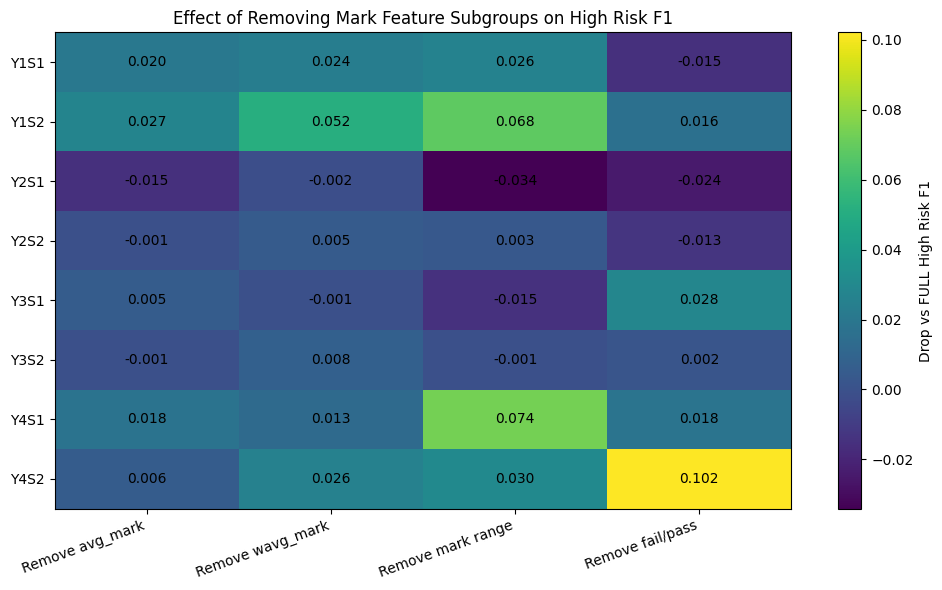

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# If drop_summary already exists, you can skip this block
drop_summary = results_df.pivot_table(
    index="sheet",
    columns="experiment",
    values="drop_vs_full_f1_highrisk"
)

# Keep only the useful columns for display
heatmap_df = drop_summary[[
    "NO_AVG_MARK",
    "NO_WAVG_MARK",
    "NO_MARK_RANGE",
    "NO_FAIL_PASS"
]].copy()

# Rename columns to cleaner labels
heatmap_df.columns = [
    "Remove avg_mark",
    "Remove wavg_mark",
    "Remove mark range",
    "Remove fail/pass"
]

# Ensure correct checkpoint order
sheet_order = ["Y1S1", "Y1S2", "Y2S1", "Y2S2", "Y3S1", "Y3S2", "Y4S1", "Y4S2"]
heatmap_df = heatmap_df.reindex(sheet_order)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(heatmap_df.values, aspect="auto")

# Axis labels
ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns, rotation=20, ha="right")
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

# Annotate each cell
for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        value = heatmap_df.iloc[i, j]
        ax.text(j, i, f"{value:.3f}", ha="center", va="center")

# Title and colorbar
ax.set_title("Effect of Removing Mark Feature Subgroups on High Risk F1")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Drop vs FULL High Risk F1")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score, accuracy_score

# FILE PATHS
gpa_path = r"C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\MasterDatasetRISK_BAND_Y4S2.xlsx"
marks_path = r"C:\Users\User\Desktop\Final Year Project\Data\FeatureDataset_RiskProgress_structuralfill_v2.xlsx"

# SETTINGS
sheet_name = "Y1S1"
gpa_col = "GPA_Y1S1"
target_col = "RISK_BAND_Y4S2"
focus_class = "High Risk"

# LOAD GPA DATA
gpa_df = pd.read_excel(gpa_path)

# convert checkpoint GPA zero to NaN
gpa_df[gpa_col] = gpa_df[gpa_col].replace(0, np.nan)

gpa_keep = ["REGNO", gpa_col, target_col]
gpa_df = gpa_df[gpa_keep].copy()

# keep only rows with target
gpa_df = gpa_df[gpa_df[target_col].notna()].copy()

# LOAD MARKS DATA
marks_df = pd.read_excel(marks_path, sheet_name=sheet_name)

marks_feature_cols = [
    "credits_attempted", "module_count",
    "wavg_mark", "avg_mark", "mark_min", "mark_max", "mark_std",
    "fail_count", "pass_count",
    "credits_L1", "credits_L2", "credits_L3", "credits_L4",
    "wavg_mark_L1", "wavg_mark_L2", "wavg_mark_L3", "wavg_mark_L4",
    "credits_T1", "credits_T2", "credits_T3", "credits_T4", "credits_T5",
    "wavg_mark_T1", "wavg_mark_T2", "wavg_mark_T3", "wavg_mark_T4", "wavg_mark_T5"
]
marks_feature_cols = [c for c in marks_feature_cols if c in marks_df.columns]

marks_keep = ["REGNO"] + marks_feature_cols + [target_col]
marks_df = marks_df[marks_keep].copy()

# keep only rows with target
marks_df = marks_df[marks_df[target_col].notna()].copy()

# MATCH BY REGNO
matched_df = marks_df.merge(
    gpa_df[["REGNO", gpa_col]],
    on="REGNO",
    how="inner"
)

print("Matched rows:", len(matched_df))
print("\nTarget distribution on matched rows:")
print(matched_df[target_col].value_counts())

print("\nMissing GPA in matched rows:")
print(matched_df[gpa_col].isna().sum())

# SCORER
def f1_one_vs_rest(y_true, y_pred, positive_label=focus_class):
    y_true_bin = (pd.Series(y_true) == positive_label).astype(int)
    y_pred_bin = (pd.Series(y_pred) == positive_label).astype(int)
    return f1_score(y_true_bin, y_pred_bin, zero_division=0)

scoring = {
    "accuracy": make_scorer(accuracy_score),
    "f1_macro": make_scorer(f1_score, average="macro"),
    "f1_highrisk": make_scorer(f1_one_vs_rest)
}

# MODEL
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# SAME ROWS FOR ALL 3
experiments = {
    "GPA_ONLY_MATCHED": [gpa_col],
    "MARKS_ONLY_MATCHED": marks_feature_cols,
    "GPA_PLUS_MARKS_MATCHED": marks_feature_cols + [gpa_col]
}

results = []

y = matched_df[target_col].copy()

for exp_name, feature_cols in experiments.items():
    X = matched_df[feature_cols].copy()

    scores = cross_validate(
        pipeline,
        X, y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score="raise"
    )

    results.append({
        "sheet": sheet_name,
        "experiment": exp_name,
        "n_rows": len(matched_df),
        "n_features": len(feature_cols),
        "accuracy_mean": scores["test_accuracy"].mean(),
        "accuracy_std": scores["test_accuracy"].std(),
        "f1_macro_mean": scores["test_f1_macro"].mean(),
        "f1_macro_std": scores["test_f1_macro"].std(),
        "f1_highrisk_mean": scores["test_f1_highrisk"].mean(),
        "f1_highrisk_std": scores["test_f1_highrisk"].std(),
    })

results_df = pd.DataFrame(results).sort_values("f1_highrisk_mean", ascending=False)

print("\nMatched comparison results:")
print(results_df)

Matched rows: 556

Target distribution on matched rows:
RISK_BAND_Y4S2
Moderate     147
Safe         128
Risk         118
Very Safe     94
High Risk     69
Name: count, dtype: int64

Missing GPA in matched rows:
0

Matched comparison results:
  sheet              experiment  n_rows  n_features  accuracy_mean  \
2  Y1S1  GPA_PLUS_MARKS_MATCHED     556          28       0.359653   
1  Y1S1      MARKS_ONLY_MATCHED     556          27       0.339897   
0  Y1S1        GPA_ONLY_MATCHED     556           1       0.278700   

   accuracy_std  f1_macro_mean  f1_macro_std  f1_highrisk_mean  \
2      0.048176       0.359408      0.047771          0.469340   
1      0.040955       0.347189      0.036529          0.456009   
0      0.031945       0.273444      0.029188          0.233754   

   f1_highrisk_std  
2         0.130824  
1         0.095284  
0         0.054509  


In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score, accuracy_score

# FILE PATHS
gpa_path = r"C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\MasterDatasetRISK_BAND_Y4S2.xlsx"
marks_path = r"C:\Users\User\Desktop\Final Year Project\Data\FeatureDataset_RiskProgress_structuralfill_v2.xlsx"
output_path = r"C:\Users\User\Desktop\Final Year Project\Data\gpa_marks_combined_comparison_all_sheets.xlsx"

# SETTINGS
target_col = "RISK_BAND_Y4S2"
focus_class = "High Risk"

sheet_to_gpa = {
    "Y1S1": "GPA_Y1S1",
    "Y1S2": "GPA_Y1S2",
    "Y2S1": "GPA_Y2S1",
    "Y2S2": "GPA_Y2S2",
    "Y3S1": "GPA_Y3S1",
    "Y3S2": "GPA_Y3S2",
    "Y4S1": "GPA_Y4S1",
    "Y4S2": "GPA_Y4S2",
}

# LOAD GPA DATA
gpa_df = pd.read_excel(gpa_path)

# convert all checkpoint GPA zeros to NaN
for gpa_col in sheet_to_gpa.values():
    if gpa_col in gpa_df.columns:
        gpa_df[gpa_col] = gpa_df[gpa_col].replace(0, np.nan)

# keep only rows with target
gpa_df = gpa_df[gpa_df[target_col].notna()].copy()

# SCORER
def f1_one_vs_rest(y_true, y_pred, positive_label=focus_class):
    y_true_bin = (pd.Series(y_true) == positive_label).astype(int)
    y_pred_bin = (pd.Series(y_pred) == positive_label).astype(int)
    return f1_score(y_true_bin, y_pred_bin, zero_division=0)

scoring = {
    "accuracy": make_scorer(accuracy_score),
    "f1_macro": make_scorer(f1_score, average="macro"),
    "f1_highrisk": make_scorer(f1_one_vs_rest)
}

# MODEL
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# RUN ALL SHEETS
xls = pd.ExcelFile(marks_path)
all_results = []

for sheet_name in xls.sheet_names:
    print(f"\nRunning checkpoint: {sheet_name}")

    gpa_col = sheet_to_gpa[sheet_name]

    # ---- load marks sheet
    marks_df = pd.read_excel(marks_path, sheet_name=sheet_name)

    marks_feature_cols = [
        "credits_attempted", "module_count",
        "wavg_mark", "avg_mark", "mark_min", "mark_max", "mark_std",
        "fail_count", "pass_count",
        "credits_L1", "credits_L2", "credits_L3", "credits_L4",
        "wavg_mark_L1", "wavg_mark_L2", "wavg_mark_L3", "wavg_mark_L4",
        "credits_T1", "credits_T2", "credits_T3", "credits_T4", "credits_T5",
        "wavg_mark_T1", "wavg_mark_T2", "wavg_mark_T3", "wavg_mark_T4", "wavg_mark_T5"
    ]
    marks_feature_cols = [c for c in marks_feature_cols if c in marks_df.columns]

    marks_df = marks_df[["REGNO"] + marks_feature_cols + [target_col]].copy()
    marks_df = marks_df[marks_df[target_col].notna()].copy()

    # ---- prepare GPA for this checkpoint
    gpa_sub = gpa_df[["REGNO", gpa_col, target_col]].copy()

    # ---- matched rows by REGNO
    matched_df = marks_df.merge(
        gpa_sub[["REGNO", gpa_col]],
        on="REGNO",
        how="inner"
    )

    print("Matched rows:", len(matched_df))
    print("Missing GPA in matched rows:", matched_df[gpa_col].isna().sum())

    y = matched_df[target_col].copy()

    experiments = {
        "GPA_ONLY": [gpa_col],
        "MARKS_ONLY": marks_feature_cols,
        "GPA_PLUS_MARKS": marks_feature_cols + [gpa_col]
    }

    for exp_name, feature_cols in experiments.items():
        X = matched_df[feature_cols].copy()

        scores = cross_validate(
            pipeline,
            X, y,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
            error_score="raise"
        )

        all_results.append({
            "sheet": sheet_name,
            "gpa_column": gpa_col,
            "experiment": exp_name,
            "n_rows": len(matched_df),
            "n_features": len(feature_cols),
            "accuracy_mean": scores["test_accuracy"].mean(),
            "accuracy_std": scores["test_accuracy"].std(),
            "f1_macro_mean": scores["test_f1_macro"].mean(),
            "f1_macro_std": scores["test_f1_macro"].std(),
            "f1_highrisk_mean": scores["test_f1_highrisk"].mean(),
            "f1_highrisk_std": scores["test_f1_highrisk"].std(),
        })

results_df = pd.DataFrame(all_results)

print("\n================ FULL RESULTS ================\n")
print(results_df.sort_values(["sheet", "f1_highrisk_mean"], ascending=[True, False]))

# save full results
results_df.to_excel(output_path, index=False)
print(f"\nSaved full results to:\n{output_path}")

# SUMMARY TABLES
summary_f1 = results_df.pivot_table(
    index="sheet",
    columns="experiment",
    values="f1_highrisk_mean"
)

summary_acc = results_df.pivot_table(
    index="sheet",
    columns="experiment",
    values="accuracy_mean"
)

print("\n================ HIGH RISK F1 SUMMARY ================\n")
print(summary_f1)

print("\n================ ACCURACY SUMMARY ================\n")
print(summary_acc)


Running checkpoint: Y1S1
Matched rows: 556
Missing GPA in matched rows: 0

Running checkpoint: Y1S2
Matched rows: 770
Missing GPA in matched rows: 1

Running checkpoint: Y2S1
Matched rows: 770
Missing GPA in matched rows: 38

Running checkpoint: Y2S2
Matched rows: 768
Missing GPA in matched rows: 2

Running checkpoint: Y3S1
Matched rows: 764
Missing GPA in matched rows: 438

Running checkpoint: Y3S2
Matched rows: 755
Missing GPA in matched rows: 666

Running checkpoint: Y4S1
Matched rows: 741
Missing GPA in matched rows: 178

Running checkpoint: Y4S2
Matched rows: 753
Missing GPA in matched rows: 45

================ FULL RESULTS ================

   sheet gpa_column      experiment  n_rows  n_features  accuracy_mean  \
2   Y1S1   GPA_Y1S1  GPA_PLUS_MARKS     556          28       0.359653   
1   Y1S1   GPA_Y1S1      MARKS_ONLY     556          27       0.339897   
0   Y1S1   GPA_Y1S1        GPA_ONLY     556           1       0.278700   
4   Y1S2   GPA_Y1S2      MARKS_ONLY     770    

In [12]:
sheet_order = ["Y1S1", "Y1S2", "Y2S1", "Y2S2", "Y3S1", "Y3S2", "Y4S1", "Y4S2"]

summary_f1 = summary_f1.reindex(sheet_order)
summary_acc = summary_acc.reindex(sheet_order)

print(summary_f1)
print(summary_acc)

experiment  GPA_ONLY  GPA_PLUS_MARKS  MARKS_ONLY
sheet                                           
Y1S1        0.233754        0.469340    0.456009
Y1S2        0.141312        0.351335    0.386741
Y2S1        0.264057        0.453820    0.431312
Y2S2        0.296476        0.493889    0.495620
Y3S1        0.276777        0.473353    0.472520
Y3S2        0.256665        0.383004    0.374782
Y4S1        0.263682        0.510694    0.513040
Y4S2        0.995349        0.960648    0.871404
experiment  GPA_ONLY  GPA_PLUS_MARKS  MARKS_ONLY
sheet                                           
Y1S1        0.278700        0.359653    0.339897
Y1S2        0.266234        0.331169    0.338961
Y2S1        0.298701        0.344156    0.344156
Y2S2        0.322910        0.442679    0.426976
Y3S1        0.213364        0.281407    0.269625
Y3S2        0.280795        0.286093    0.284768
Y4S1        0.314448        0.403492    0.389978
Y4S2        0.998675        0.982728    0.787497


In [13]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score, accuracy_score

# FILE PATHS
gpa_path = r"C:\Users\User\Desktop\Final Year Project\22b6023 Muizzul\3 Processed Data\MasterDatasetRISK_BAND_Y4S2.xlsx"
marks_path = r"C:\Users\User\Desktop\Final Year Project\Data\FeatureDataset_RiskProgress_structuralfill_v2.xlsx"
output_path = r"C:\Users\User\Desktop\Final Year Project\Data\cum_gpa_marks_comparison_all_sheets.xlsx"

# SETTINGS
target_col = "RISK_BAND_Y4S2"
focus_class = "High Risk"

checkpoint_to_gpa_history = {
    "Y1S1": ["GPA_Y1S1"],
    "Y1S2": ["GPA_Y1S1", "GPA_Y1S2"],
    "Y2S1": ["GPA_Y1S1", "GPA_Y1S2", "GPA_Y2S1"],
    "Y2S2": ["GPA_Y1S1", "GPA_Y1S2", "GPA_Y2S1", "GPA_Y2S2"],
    "Y3S1": ["GPA_Y1S1", "GPA_Y1S2", "GPA_Y2S1", "GPA_Y2S2", "GPA_Y3S1"],
    "Y3S2": ["GPA_Y1S1", "GPA_Y1S2", "GPA_Y2S1", "GPA_Y2S2", "GPA_Y3S1", "GPA_Y3S2"],
    "Y4S1": ["GPA_Y1S1", "GPA_Y1S2", "GPA_Y2S1", "GPA_Y2S2", "GPA_Y3S1", "GPA_Y3S2", "GPA_Y4S1"],
    "Y4S2": ["GPA_Y1S1", "GPA_Y1S2", "GPA_Y2S1", "GPA_Y2S2", "GPA_Y3S1", "GPA_Y3S2", "GPA_Y4S1", "GPA_Y4S2"],
}

marks_feature_template = [
    "credits_attempted", "module_count",
    "wavg_mark", "avg_mark", "mark_min", "mark_max", "mark_std",
    "fail_count", "pass_count",
    "credits_L1", "credits_L2", "credits_L3", "credits_L4",
    "wavg_mark_L1", "wavg_mark_L2", "wavg_mark_L3", "wavg_mark_L4",
    "credits_T1", "credits_T2", "credits_T3", "credits_T4", "credits_T5",
    "wavg_mark_T1", "wavg_mark_T2", "wavg_mark_T3", "wavg_mark_T4", "wavg_mark_T5"
]

sheet_order = ["Y1S1", "Y1S2", "Y2S1", "Y2S2", "Y3S1", "Y3S2", "Y4S1", "Y4S2"]

# LOAD GPA DATA
gpa_df = pd.read_excel(gpa_path)

# Convert all checkpoint GPA zeros to NaN
all_gpa_cols = sorted({col for cols in checkpoint_to_gpa_history.values() for col in cols})
for col in all_gpa_cols:
    if col in gpa_df.columns:
        gpa_df[col] = gpa_df[col].replace(0, np.nan)

# Keep only rows with target
gpa_df = gpa_df[gpa_df[target_col].notna()].copy()

# SCORING
def f1_one_vs_rest(y_true, y_pred, positive_label=focus_class):
    y_true_bin = (pd.Series(y_true) == positive_label).astype(int)
    y_pred_bin = (pd.Series(y_pred) == positive_label).astype(int)
    return f1_score(y_true_bin, y_pred_bin, zero_division=0)

scoring = {
    "accuracy": make_scorer(accuracy_score),
    "f1_macro": make_scorer(f1_score, average="macro"),
    "f1_highrisk": make_scorer(f1_one_vs_rest)
}

# MODEL
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# RUN ALL CHECKPOINTS
xls = pd.ExcelFile(marks_path)
all_results = []

for sheet_name in sheet_order:
    print(f"\nRunning checkpoint: {sheet_name}")

    # ---- GPA history for this checkpoint
    gpa_cols = checkpoint_to_gpa_history[sheet_name]

    # ---- load marks sheet
    marks_df = pd.read_excel(marks_path, sheet_name=sheet_name)
    marks_feature_cols = [c for c in marks_feature_template if c in marks_df.columns]

    marks_df = marks_df[["REGNO"] + marks_feature_cols + [target_col]].copy()
    marks_df = marks_df[marks_df[target_col].notna()].copy()

    # ---- GPA subset
    gpa_sub = gpa_df[["REGNO"] + gpa_cols + [target_col]].copy()

    # ---- match by REGNO
    matched_df = marks_df.merge(
        gpa_sub[["REGNO"] + gpa_cols],
        on="REGNO",
        how="inner"
    )

    print("Matched rows:", len(matched_df))
    print("Missing GPA values in matched rows:")
    print(matched_df[gpa_cols].isna().sum())

    y = matched_df[target_col].copy()

    experiments = {
        "CUM_GPA_ONLY": gpa_cols,
        "MARKS_ONLY": marks_feature_cols,
        "CUM_GPA_PLUS_MARKS": gpa_cols + marks_feature_cols
    }

    for exp_name, feature_cols in experiments.items():
        X = matched_df[feature_cols].copy()

        scores = cross_validate(
            pipeline,
            X, y,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
            error_score="raise"
        )

        all_results.append({
            "sheet": sheet_name,
            "experiment": exp_name,
            "n_rows": len(matched_df),
            "n_features": len(feature_cols),
            "gpa_features_used": ", ".join(gpa_cols),
            "accuracy_mean": scores["test_accuracy"].mean(),
            "accuracy_std": scores["test_accuracy"].std(),
            "f1_macro_mean": scores["test_f1_macro"].mean(),
            "f1_macro_std": scores["test_f1_macro"].std(),
            "f1_highrisk_mean": scores["test_f1_highrisk"].mean(),
            "f1_highrisk_std": scores["test_f1_highrisk"].std(),
        })

results_df = pd.DataFrame(all_results)

print("\n================ FULL RESULTS ================\n")
print(results_df.sort_values(["sheet", "f1_highrisk_mean"], ascending=[True, False]))

# save
results_df.to_excel(output_path, index=False)
print(f"\nSaved full results to:\n{output_path}")

# SUMMARY TABLES
summary_f1 = results_df.pivot_table(
    index="sheet",
    columns="experiment",
    values="f1_highrisk_mean"
).reindex(sheet_order)

summary_acc = results_df.pivot_table(
    index="sheet",
    columns="experiment",
    values="accuracy_mean"
).reindex(sheet_order)

print("\n================ HIGH RISK F1 SUMMARY ================\n")
print(summary_f1)

print("\n================ ACCURACY SUMMARY ================\n")
print(summary_acc)


Running checkpoint: Y1S1
Matched rows: 556
Missing GPA values in matched rows:
GPA_Y1S1    0
dtype: int64

Running checkpoint: Y1S2
Matched rows: 770
Missing GPA values in matched rows:
GPA_Y1S1    215
GPA_Y1S2      1
dtype: int64

Running checkpoint: Y2S1
Matched rows: 770
Missing GPA values in matched rows:
GPA_Y1S1    215
GPA_Y1S2      2
GPA_Y2S1     38
dtype: int64

Running checkpoint: Y2S2
Matched rows: 768
Missing GPA values in matched rows:
GPA_Y1S1    214
GPA_Y1S2      2
GPA_Y2S1     39
GPA_Y2S2      2
dtype: int64

Running checkpoint: Y3S1
Matched rows: 764
Missing GPA values in matched rows:
GPA_Y1S1    214
GPA_Y1S2      2
GPA_Y2S1     39
GPA_Y2S2      3
GPA_Y3S1    438
dtype: int64

Running checkpoint: Y3S2
Matched rows: 755
Missing GPA values in matched rows:
GPA_Y1S1    208
GPA_Y1S2      2
GPA_Y2S1     39
GPA_Y2S2      3
GPA_Y3S1    437
GPA_Y3S2    666
dtype: int64

Running checkpoint: Y4S1
Matched rows: 741
Missing GPA values in matched rows:
GPA_Y1S1    187
GPA_Y1S2    

In [14]:
comparison = summary_f1.copy()
comparison["CUM_GPA_gain_vs_MARKS"] = comparison["CUM_GPA_ONLY"] - comparison["MARKS_ONLY"]
comparison["COMBINED_gain_vs_MARKS"] = comparison["CUM_GPA_PLUS_MARKS"] - comparison["MARKS_ONLY"]
comparison["COMBINED_gain_vs_CUM_GPA"] = comparison["CUM_GPA_PLUS_MARKS"] - comparison["CUM_GPA_ONLY"]

print(comparison)

experiment  CUM_GPA_ONLY  CUM_GPA_PLUS_MARKS  MARKS_ONLY  \
sheet                                                      
Y1S1            0.233754            0.471279    0.456009   
Y1S2            0.208075            0.332885    0.386741   
Y2S1            0.203499            0.442592    0.431312   
Y2S2            0.241623            0.479688    0.495620   
Y3S1            0.270137            0.574825    0.472520   
Y3S2            0.395227            0.437624    0.374782   
Y4S1            0.456326            0.573041    0.513040   
Y4S2            0.829405            0.940271    0.871404   

experiment  CUM_GPA_gain_vs_MARKS  COMBINED_gain_vs_MARKS  \
sheet                                                       
Y1S1                    -0.222255                0.015270   
Y1S2                    -0.178666               -0.053856   
Y2S1                    -0.227813                0.011280   
Y2S2                    -0.253996               -0.015931   
Y3S1                    -0.202382

In [ ]:
import pandas as pd

# )

# Reorder checkpoints
sheet_order = ["Y1S1", "Y1S2", "Y2S1", "Y2S2", "Y3S1", "Y3S2", "Y4S1", "Y4S2"]
summary_f1 = summary_f1.reindex(sheet_order)

# Select and rename columns
final_summary = summary_f1[[
    "MARKS_ONLY",
    "CUM_GPA_PLUS_MARKS",
    "CUM_GPA_ONLY"
]].copy()

final_summary.columns = [
    "Marks-only",
    "Marks + Cumulative GPA",
    "Cumulative GPA-only"
]

# Round values to 3 decimals
final_summary = final_summary.round(3)

print(final_summary)

       Marks-only  Marks + Cumulative GPA  Cumulative GPA-only
sheet                                                         
Y1S1        0.456                   0.471                0.234
Y1S2        0.387                   0.333                0.208
Y2S1        0.431                   0.443                0.203
Y2S2        0.496                   0.480                0.242
Y3S1        0.473                   0.575                0.270
Y3S2        0.375                   0.438                0.395
Y4S1        0.513                   0.573                0.456
Y4S2        0.871                   0.940                0.829
